In [2]:



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU


np.random.seed(42)

In [3]:

data = np.sin(np.arange(0, 100, 0.1))


scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1, 1))


def create_dataset(data, time_steps=10):
    X, y = [], []
    for i in range(len(data)-time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

time_steps = 10
X, y = create_dataset(data, time_steps)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [4]:
model_rnn = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(time_steps, 1)),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Prediction
y_pred_rnn = model_rnn.predict(X_test)
mse_rnn = mean_squared_error(y_test, y_pred_rnn)

print("RNN MSE:", mse_rnn)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.3686 - val_loss: 0.0624
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0460 - val_loss: 0.0187
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0111 - val_loss: 0.0042
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0031 - val_loss: 0.0024
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 - val_loss: 9.9652e-04
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.7282e-04 - val_loss: 8.3486e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
RNN MSE: 0.0008348635592233903


In [5]:
model_lstm = Sequential([
    LSTM(50, activation='tanh', input_shape=(time_steps, 1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Prediction
y_pred_lstm = model_lstm.predict(X_test)
mse_lstm = mean_squared_error(y_test, y_pred_lstm)

print("LSTM MSE:", mse_lstm)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1727 - val_loss: 0.0443
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0359 - val_loss: 0.0284
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0272 - val_loss: 0.0241
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0233 - val_loss: 0.0206
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0196 - val_loss: 0.0168
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0151 - val_loss: 0.0118
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0093 - val_loss: 0.0057
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0037 - val_loss: 0.0021
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0013 - val_loss: 0.0012
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
LSTM MSE: 0.0012330738947750196


In [6]:
model_gru = Sequential([
    GRU(50, activation='tanh', input_shape=(time_steps, 1)),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

y_pred_gru = model_gru.predict(X_test)
mse_gru = mean_squared_error(y_test, y_pred_gru)

print("GRU MSE:", mse_gru)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0988 - val_loss: 0.0369
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0215 - val_loss: 0.0145
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0118 - val_loss: 0.0090
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0082 - val_loss: 0.0068
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0063 - val_loss: 0.0053
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0047 - val_loss: 0.0039
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0031 - val_loss: 0.0022
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0015 - val_loss: 7.5056e-04
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.4668e-04 - val_loss: 2.6812e-04
Epoch 10/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.1450e-04 - val_loss: 1.7530e-04


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
GRU MSE: 0.0001752984569213972


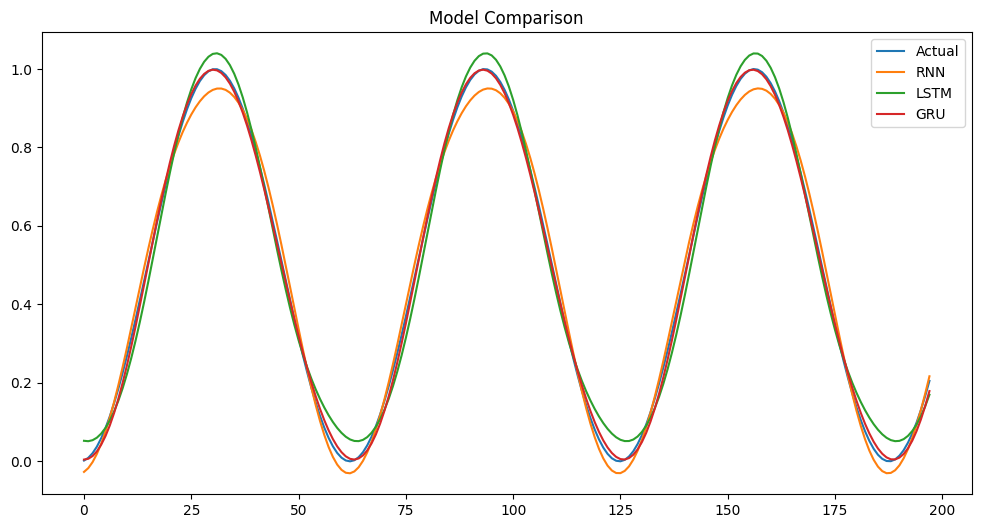

In [7]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label="Actual")
plt.plot(y_pred_rnn, label="RNN")
plt.plot(y_pred_lstm, label="LSTM")
plt.plot(y_pred_gru, label="GRU")
plt.legend()
plt.title("Model Comparison")
plt.show()

In [8]:
print("Final Comparison:")
print(f"RNN  MSE: {mse_rnn}")
print(f"LSTM MSE: {mse_lstm}")
print(f"GRU  MSE: {mse_gru}")

Final Comparison:
RNN  MSE: 0.0008348635592233903
LSTM MSE: 0.0012330738947750196
GRU  MSE: 0.0001752984569213972
